# Signal Processing for Machine Learning

The project is about signal classification using machine learning (ML). Given a dataset and classification problem, the goal is to find a configuration for the frontend DSP stage that minimizes data storage requirements (creating a new version of the dataset), computational cost of the ML stage, and maximizes accuracy.

The designer is allowed to work with two degrees of freedom:

1) decimation factor
2) design and use of quantizers (uniform or non-uniform)

It is prohibited to change the ML stage (you cannot change the classifier).

Signal classification pipeline (e.g., with pathology / without pathology):
1) data representation optimization (decimation, bit-depth reduction) → 2) classification → 3) feedback loop to the optimization stage with analysis of the impact on classification performance → 4) search for the configuration that minimizes data storage requirements, computational cost, and maximizes accuracy.

# Execute resampling and quantization to create a new dataset

Learn:
* how to recursively find all files within a folder
* deal with compressed files with headers (PNG format) and raw binary files
* use Python modules from packages that are not part of a well-known library, to train using (and later creating your own) a customized library. In this case it will be lasse-py.

In [25]:
# =========================================
# Clone repo
# =========================================
!git clone https://github.com/lasseufpa/lasse-py.git

# Move into repo
%cd lasse-py

# =========================================
# Install as editable package
# =========================================
!pip install -e .

# =========================================
# (Optional) Verify installation
# =========================================
import importlib

try:
    import lasse
    print("lasse package found at:", lasse.__file__)
except Exception as e:
    print("Import failed:", e)

# =========================================
# Test your specific import
# =========================================
from lasse.dsp.scalar_quantization import Quantizer
from lasse.dsp.scalar_quantization import UniformQuantizer
from lasse.dsp.scalar_quantization import NonUniformQuantizer

print("Imports successful.")

C:\Users\abrkl\Downloads\lasse-py\lasse-py


Cloning into 'lasse-py'...


Obtaining file:///C:/Users/abrkl/Downloads/lasse-py/lasse-py
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Checking if build backend supports build_editable: started
  Checking if build backend supports build_editable: finished with status 'done'
  Getting requirements to build editable: started
  Getting requirements to build editable: finished with status 'done'
  Preparing editable metadata (pyproject.toml): started
  Preparing editable metadata (pyproject.toml): finished with status 'done'
  Building editable for lasse-py (pyproject.toml): started
  Building editable for lasse-py (pyproject.toml): finished with status 'done'
  Created wheel for lasse-py: filename=lasse_py-0.0.1-0.editable-py3-none-any.whl size=15264 sha256=06fef6e087b7b819f8c50b406e33ce75fd8d5c94f6f29153f9be49d08a781511
  Stored in directory: C:\Users\abrkl\AppData\Local\Temp\pip-ephem-wheel-cache-sl82zhal\wheels\9a\34\62\c075016b44e98161b50077a896b894918808

In [26]:
# Define "global" variables
DATASET_URL = "https://nextcloud.lasseufpa.org/s/q7KHGqfX4BrB6oT/download"
NUM_BITS = 5 # number of bits per sample
DECIMATION_FACTOR = 4 # design decision: choose a decimation factor
LASSE_PY_PATH = "/github/lasse-py" # folder where lasse-py was installed. It will be added to PYTHONPATH
RAW_FILES_PATH = './cifarsubset10'
ZIP_FILE_NAME = 'cifarsubset10.zip'
PROCESSED_FILES_PATH = './new_dataset'
RAW_FILES_EXTENSION = '.png'
PROCESSED_FILES_EXTENSION = '.bin'


In [27]:
import os
import requests
import zipfile
from tqdm import tqdm

def prepare_dataset(
    url,
    zip_name="dataset.zip",
    extract_dir="dataset",
    force_download=False
):
    """
    Download a ZIP dataset, extract it, and return the path.

    Parameters
    ----------
    url : str
        Direct URL to the dataset ZIP file
    zip_name : str
        Local filename for downloaded ZIP
    extract_dir : str
        Directory where dataset will be extracted
    force_download : bool
        If True, re-download even if file exists

    Returns
    -------
    extract_dir : str
        Path to extracted dataset
    """

    # =============================
    # Step 1: Download
    # =============================
    if force_download or not os.path.exists(zip_name):
        print("Downloading dataset...")
        response = requests.get(url, stream=True)

        if response.status_code != 200:
            raise RuntimeError(f"Download failed: {response.status_code}")

        with open(zip_name, "wb") as f:
            for chunk in tqdm(response.iter_content(8192)):
                f.write(chunk)

        print("Download complete.")
    else:
        print("ZIP already exists. Skipping download.")

    # =============================
    # Step 2: Extract
    # =============================
    if not os.path.exists(extract_dir):
        print("Extracting dataset...")
        with zipfile.ZipFile(zip_name, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print("Extraction complete.")
    else:
        print("Dataset already extracted.")

    return extract_dir

In [28]:
dataset_path = prepare_dataset(
    DATASET_URL,
    zip_name=ZIP_FILE_NAME,
    extract_dir=RAW_FILES_PATH
)

print("Dataset ready at:", dataset_path)

10972it [00:10, 1082.83it/s]


Download complete.
Extracting dataset...
Extraction complete.
Dataset ready at: ./cifarsubset10


In [29]:
# TO DO
# Save to Google Drive (avoid re-download)
if False:
    from google.colab import drive
    drive.mount('/content/drive')

    # move dataset
    !cp -r aa_dataset /content/drive/MyDrive/

In [30]:
# Code for calculating MSE and PSNR:
import numpy as np

def compute_mse(x1, x2):
    diff = x1.astype(np.float64) - x2.astype(np.float64)
    return np.mean(diff ** 2)

def compute_psnr(mse, max_pixel=255.0):
    if mse == 0:
        return float("inf")
    return 10 * np.log10((max_pixel ** 2) / mse)

def print_mse_and_psnr(x1, x2):
    mse = compute_mse(x1, x2)
    peak_value = np.max([np.max(x1), np.max(x2)])
    psnr = compute_psnr(mse, max_pixel=peak_value)
    print(f"MSE: {mse:.2f}, PSNR: {psnr:.2f} dB")

In [31]:
# Code for decimation (no filtering):
import numpy as np

# Decimate an image
from PIL import Image

def decimate_image(image_as_array: np.ndarray, decimation_factor: int):
    # Implement pure decimation (no filtering)
    decimated = image_as_array[::decimation_factor, ::decimation_factor]
    return decimated

In [32]:
import numpy as np
import math

def unflatten_to_image(x, enforce_uint8=True, rescale_if_needed=True):
    """
    Convert a flattened RGB vector into an image array by inferring dimensions.

    Assumes layout:
    [R (H*W), G (H*W), B (H*W)].

    Parameters
    ----------
    x : np.ndarray
        1D array of length 3 * H * W.

    enforce_uint8 : bool
        If True, output will be uint8 in [0, 255].

    rescale_if_needed : bool
        If True, automatically rescales data to [0,255] if outside range.
        If False, raises ValueError when out of range.

    Returns
    -------
    np.ndarray
        Image of shape (H, W, 3).

    Raises
    ------
    ValueError
        If size is invalid or range is invalid (when rescale_if_needed=False).
    """
    x = np.asarray(x)
    N = x.size

    # ---- shape inference ----
    if N % 3 != 0:
        raise ValueError(f"Vector length {N} is not divisible by 3")

    pixels = N // 3
    side = int(math.isqrt(pixels))

    if side * side != pixels:
        raise ValueError(f"Cannot infer square image dimensions from {N} elements")

    # ---- reshape ----
    try:
        img = x.reshape(3, side, side)
        img = np.transpose(img, (1, 2, 0))
    except Exception as e:
        raise ValueError(f"Failed to reshape into image: {e}")

    # ---- range handling ----
    min_val = img.min()
    max_val = img.max()

    if enforce_uint8:
        if 0 <= min_val and max_val <= 255:
            # already valid → just cast
            img = img.astype(np.uint8)

        else:
            if not rescale_if_needed:
                raise ValueError(
                    f"Image values out of range [0,255]: min={min_val}, max={max_val}"
                )

            # avoid division by zero
            if max_val == min_val:
                img = np.zeros_like(img, dtype=np.uint8)
            else:
                # linear normalization to [0,255]
                img = (img - min_val) / (max_val - min_val)
                img = (img * 255).astype(np.uint8)

    return img

In [51]:
from IPython.display import clear_output
import matplotlib.pyplot as plt

def compute_spectrum(img_array):
    """
    Compute log-magnitude 2D Fourier spectrum
    """
    if img_array.ndim == 3:
        img_gray = np.mean(img_array, axis=2)
    else:
        img_gray = img_array

    F = np.fft.fft2(img_gray)
    F_shift = np.fft.fftshift(F)

    magnitude = np.abs(F_shift)
    spectrum = np.log1p(magnitude)

    return spectrum


def show_image_and_spectrum(img_array, spectrum, title=""):
    clear_output(wait=True)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(img_array.astype('uint8'))
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(spectrum, cmap="gray")
    axes[1].set_title("2D Spectrum (log scale)")
    axes[1].axis("off")

    if title:
        fig.suptitle(title)

    plt.tight_layout()
    plt.show()

In [52]:

# Code for quantization:
# install from https://github.com/lasseufpa/lasse-py
# and configure your PYTHONPATH to point to the folder
# in which the package is installed, e.g. with something like:
import sys
import numpy as np
sys.path.append(LASSE_PY_PATH) # add to PYTHONPATH
from lasse.dsp.scalar_quantization import Quantizer
from lasse.dsp.scalar_quantization import UniformQuantizer
from lasse.dsp.scalar_quantization import NonUniformQuantizer


def estimate_bits_from_snr(snr_db, sigma=1.0, k=3.0):
    """
    Estimate required number of quantization bits for a Gaussian signal
    using the linear model for quantization.
    The signal is assumed to be Gaussian and clipping ignored in formula
    If k is too small, the overload distortion dominates.
    and the formula becomes optimistic.

    Parameters:
        snr_db (float): Target SNR in dB
        sigma (float): Standard deviation of input signal
        k (float): Dynamic range factor (A = k * sigma)

    Returns:
        int: number of bits
    """

    # Convert SNR to linear scale
    snr_linear = 10 ** (snr_db / 10.0)

    # Estimate the "granular" dynamic range
    A = k * sigma # increase k to decrease chances of overloading

    # Compute bits (you should be able to deduce this equation)
    B = 1 + 0.5 * np.log2((snr_linear * A**2) / (12 * sigma**2))

    return int(np.ceil(B))

def design_uniform_quantizer(x: np.ndarray, target_SNRdB: float):
    # Design a quantizer
    sigma = np.std(x)
    dynamic_range_factor_k = 3 # this is a designer decision
    num_bits = estimate_bits_from_snr(target_SNRdB, sigma=sigma, k=dynamic_range_factor_k)
    force_midtread = False
    xmin = -dynamic_range_factor_k * sigma
    xmax = dynamic_range_factor_k * sigma
    delta, xminq = UniformQuantizer.design_quantizer(num_bits, xmin, xmax, force_midtread=force_midtread)
    return UniformQuantizer(num_bits, delta, xminq)

def design_non_uniform_quantizer(x: np.ndarray, num_bits: int):
    # Design a quantizer using Lloyd-Max algorithm
    quantization_levels, thresholds = NonUniformQuantizer.design_quantizer(x, num_bits, max_iter=30, tol=1e-8)
    return NonUniformQuantizer(num_bits, quantization_levels, thresholds)


In [53]:

import os

def find_all_files(input_path, extension):
    files = []
    for root, dirs, filenames in os.walk(input_path):
        for filename in filenames:
            if filename.endswith(extension):
                files.append(os.path.join(root, filename))
    return files

def output_file_name(file_path, input_root, output_root, new_ext):
    # relative path from input root
    rel_path = os.path.relpath(file_path, input_root)

    # remove old extension and add new one
    rel_path_no_ext = os.path.splitext(rel_path)[0] + new_ext

    # build full output path
    output_file = os.path.join(output_root, rel_path_no_ext)

    # Ensure output directory exists
    os.makedirs(os.path.dirname(output_file), exist_ok=True)

    return output_file

In [54]:
# Information about struct to construct headers:
# https://docs.python.org/3/library/struct.html
# https://stackoverflow.com/questions/14970775/writing-and-reading-headers-with-struct
import struct

def create_header_for_uniform_quantizer(quantizer: UniformQuantizer) -> bytes:
    magic = b"unifor\0" # file signature with 7 bytes
    xminq, delta, num_bits = quantizer.get_parameters()

    header = struct.pack(
        "<7sBdd",  # little-endian
        magic, # 7 bytes
        num_bits, # 1 byte
        delta, # 8 bytes
        xminq # 8 bytes
        )
    return header

def create_header_for_non_uniform_quantizer(quantizer: NonUniformQuantizer) -> bytes:
    magic = b"nonuni\0" # file signature with 7 bytes
    quantizerLevels, partitionThresholds, num_bits = quantizer.get_parameters()

    # fixed part of the header
    header = struct.pack(
        "<7sB",  # little-endian
        magic, # 7 bytes
        num_bits # 1 byte
        )

    # variable-length part of the header written as doubles
    header += (np.asarray(quantizerLevels, dtype='<f8')).tobytes() # little-endian float64
    header += (np.asarray(partitionThresholds, dtype='<f8')).tobytes()
    return header

def num_of_bytes_in_header_for_nonuniform_quantizer(num_bits: int) -> int:
    # 7 bytes for magic, 1 byte for num_bits, 8 bytes for delta, 8 bytes for xminq
    M = (1 << num_bits) # number of quantization levels
    num_bytes_for_quantizerLevels = 8 * M # 1 float64 per value
    num_bytes_for_partitionThresholds = 8 * (M-1) # 1 float64 per value
    return 8 + num_bytes_for_quantizerLevels + num_bytes_for_partitionThresholds

def interpret_header_for_uniform_quantizer(header: bytes) -> NonUniformQuantizer:
    magic, num_bits, delta, xminq = struct.unpack("<7sBdd")
    return UniformQuantizer(num_bits, delta, xminq)

def interpret_header_for_non_uniform_quantizer(header: bytes) -> NonUniformQuantizer:
    magic, num_bits = struct.unpack("<7sB", header[:8])
    num_of_levels = 1 << num_bits
    num_bytes_per_value = 8
    start_byte = 8 # header has 8 bytes
    end_byte = (num_of_levels+1)*num_bytes_per_value
    quantizerLevels = np.frombuffer(header[start_byte:end_byte], dtype='<f8')
    start_byte = end_byte
    end_byte = (2*num_of_levels)*num_bytes_per_value
    partitionThresholds = np.frombuffer(header[start_byte:end_byte], dtype='<f8')
    return NonUniformQuantizer(num_bits, quantizerLevels, partitionThresholds)

In [55]:
import os
from lasse.io.compressed_files import write_encoded_file
from lasse.io.compressed_files import read_encoded_file

def process_all_images(list_of_files, input_root_folder, output_root_folder):

    img_counter = 0 # counter
    for file_path in list_of_files:
        if os.path.isfile(file_path):
            # print(f"Processing file {file_path}")
            pass
        else:
            raise FileNotFoundError(f"Error: File not found at {file_path}")

        # Process the image here
        img = Image.open(file_path) # read image from input file
        img = img.convert("RGB")  # ensure a consistent format
        arr = np.array(img) # convert to numpy array

        # decimate image
        decimated_image = decimate_image(arr, DECIMATION_FACTOR)

        if True and img_counter < 10: # enable to see an image with the 2D spectrum
            spectrum = compute_spectrum(decimated_image)
            show_image_and_spectrum(decimated_image, spectrum, title=str(file_path))
        

        # design a quantizer
        quantizer = design_non_uniform_quantizer(decimated_image, NUM_BITS)
        # Do the quantization using a uniform or non-uniform quantizer quantizer
        xq, xi = quantizer.quantize(decimated_image)
        print_mse_and_psnr(decimated_image, xq)

        # create header
        header = create_header_for_non_uniform_quantizer(quantizer)

        # output file name is the same as the input, including all subfolders, but just changing the output folder and extensio
        new_extension = '.bin' # designer decision
        output_file = output_file_name(file_path, input_root_folder, output_root_folder, new_extension)
        # write encoded file
        write_encoded_file(xi, NUM_BITS, output_file, header)

        print("Wrote file ", output_file)
        img_counter += 1


In [56]:
def create_new_dataset():
    list_of_files = find_all_files(RAW_FILES_PATH, RAW_FILES_EXTENSION)

    process_all_images(list_of_files, RAW_FILES_PATH, PROCESSED_FILES_PATH)

    print("Done. All files processed.")

In [57]:
from pathlib import Path

def extract_class_from_path(file_path, class_names_set):
    """
    Extract exactly one class name from a file path.

    Parameters
    ----------
    file_path : str or Path
    class_names : iterable of str

    Returns
    -------
    str : the matched class name

    Raises
    ------
    ValueError : if zero or multiple matches are found
    """
    p = Path(file_path)

    # scan all parts of the path
    matches = [part for part in p.parts if part in class_names_set]

    if len(matches) == 0:
        raise ValueError(f"No class name found in path: {file_path}")

    if len(matches) > 1:
        raise ValueError(f"Multiple class names found in path: {matches}")

    return matches[0]

In [58]:
# Run machine learning training and testing
from pathlib import Path
import numpy as np
from lasse.io.compressed_files import read_encoded_file


# =========================
# Data loading
# =========================
def compose_train_test_sets(list_of_files, PROCESSED_FILES_PATH):
    X = []
    y = []

    root = Path(PROCESSED_FILES_PATH)

    class_names = sorted([p.name for p in root.iterdir() if p.is_dir()])
    class_names_set = set(class_names)
    class_to_idx = {name: i for i, name in enumerate(class_names)}

    print("Classes:", class_names)

    for file_path in list_of_files:
        if os.path.isfile(file_path):
            # print(f"Processing file {file_path}")
            pass
        else:
            raise FileNotFoundError(f"Error: File not found at {file_path}")

        class_name = extract_class_from_path(file_path, class_names_set)

        # calculate the number of header bytes:
        num_header_bytes = num_of_bytes_in_header_for_nonuniform_quantizer(NUM_BITS)
        # now, read the file, create the quantizer and dequantize
        uncompressed, header = read_encoded_file(file_path, NUM_BITS, num_header_bytes = num_header_bytes)
        nonUniformQuantizer = interpret_header_for_non_uniform_quantizer(header)
        dequantized_signal = nonUniformQuantizer.dequantize(uncompressed)

        # add this example (X, y) with input / output pair for machine learning
        X.append(dequantized_signal.flatten())
        y.append(class_to_idx[class_name])

    return np.array(X), np.array(y), class_names


In [59]:
import matplotlib.pyplot as plt

# =========================
# Plot confusion matrix
# =========================
def plot_confusion_matrix(cm, class_names, normalize=False):
    if normalize:
        cm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)

    plt.figure()
    plt.imshow(cm)
    plt.title("Confusion Matrix" + (" (Normalized)" if normalize else ""))
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    # Annotate cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            text = f"{value:.2f}" if normalize else f"{int(value)}"
            plt.text(j, i, text, ha="center", va="center")

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()



In [60]:

import os

def compute_total_size(file_paths):
    """
    Compute total size of files.

    Parameters
    ----------
    file_paths : iterable of str or Path

    Returns
    -------
    total_bytes : int
    total_megabytes : float
    """
    total_bytes = 0
    missing_files = []

    for path in file_paths:
        try:
            size = os.path.getsize(path)  # actual file size in bytes
            total_bytes += size
        except OSError:
            # file not found or inaccessible
            missing_files.append(path)

    total_megabytes = total_bytes / (1024 ** 2)

    print("From a total number of files =", len(file_paths))
    print(f"Total bytes = {total_bytes} bytes, {total_megabytes:.2f} MB. Number of discarded files:", len(missing_files))
    return total_bytes, total_megabytes, missing_files

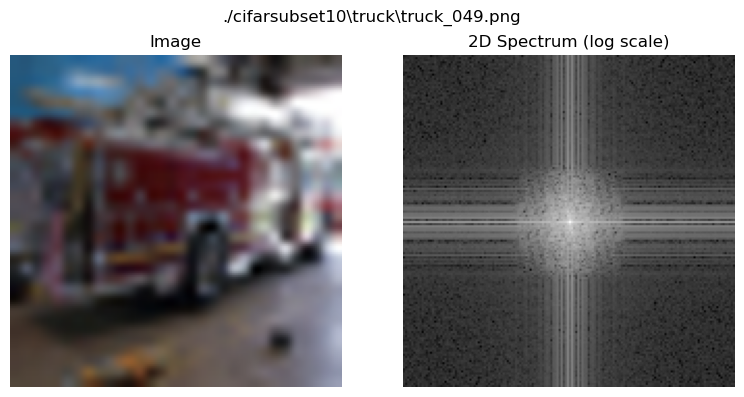

MSE: 5.37, PSNR: 40.83 dB
Wrote file  ./new_dataset\truck\truck_049.bin
Done. All files processed.


In [61]:
# Execute the method:
create_new_dataset()

In [62]:
# Feature extraction for images

import numpy as np
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray

def extract_features(image):
    """
    Extract a compact and discriminative feature vector from an RGB image
    by combining gradient-based, color, and texture descriptors.

    This method is designed for use with classical machine learning models
    (e.g., SVM, Random Forest) that require fixed-length feature vectors
    and do not exploit spatial structure directly.

    The extracted features include:
    - Histogram of Oriented Gradients (HOG): captures edge directions and
    local shape information from the grayscale version of the image.
    - Color statistics: per-channel mean and standard deviation, encoding
    global color distribution.
    - Local Binary Patterns (LBP): texture descriptor computed on the
    grayscale image, summarized as a normalized histogram.

    The final feature vector is the concatenation of all descriptors,
    providing a balanced representation of shape, appearance, and texture.

    Parameters
    ----------
    image : np.ndarray
        Input image of shape (H, W, 3), assumed to be in RGB format.
        Can be of type uint8 or float.

    Returns
    -------
    np.ndarray
        One-dimensional feature vector suitable for input to standard
        classifiers.

    Notes
    -----
    - The method is particularly effective for small images (e.g., CIFAR-like).
    - Feature scaling (e.g., StandardScaler) is recommended before classification.
    - This approach significantly outperforms raw pixel features for
    classical ML models.
        image: numpy array (H, W, 3), uint8 or float

        returns: 1D feature vector
    """

    # ---- 1. HOG (on grayscale) ----
    gray = rgb2gray(image)

    hog_feat = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        feature_vector=True
    )

    # ---- 2. Color statistics ----
    mean = image.mean(axis=(0, 1))
    std = image.std(axis=(0, 1))

    color_feat = np.concatenate([mean, std])  # 6 dims

    # ---- 3. LBP (texture) ----
    # Convert to uint8 BEFORE LBP
    gray_uint8 = (gray * 255).astype(np.uint8)

    lbp = local_binary_pattern(gray_uint8, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(lbp, bins=10, range=(0, 10), density=True)

    # ---- concatenate all ----
    return np.concatenate([hog_feat, color_feat, lbp_hist])

In [67]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

def train_and_test_ML_model(X, y, class_names):

    print(f"Dataset shape: {X.shape}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    if True:
      model = Pipeline([
          ("scaler", StandardScaler()),
          #("svm", LinearSVC(C=100))
          ("svm", SVC(kernel="rbf", C=10, gamma="scale"))
      ])
    else:
      model = Pipeline([
          # we don't need to scale the data for the decision tree
          ("decision_tree", DecisionTreeClassifier(criterion="entropy", max_depth=50))
      ])


    print("Training model...")
    model.fit(X_train, y_train)

    print("Evaluating...")
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy: {acc:.4f}\n")

    print("Classification report:")
    print(classification_report(y_test, y_pred, target_names=class_names))

    # =========================
    # Confusion matrix
    # =========================
    cm = confusion_matrix(y_test, y_pred)

    #print("\nConfusion Matrix:")
    #print(cm)

    # Plot (raw counts)
    plot_confusion_matrix(cm, class_names, normalize=False)

    # Plot (normalized)
    plot_confusion_matrix(cm, class_names, normalize=True)



In [68]:
from PIL import Image
from IPython.display import clear_output
import matplotlib.pyplot as plt

def execute_machine_learning_stage():
    list_of_files = find_all_files(PROCESSED_FILES_PATH, PROCESSED_FILES_EXTENSION)

    X, y, class_names = compose_train_test_sets(list_of_files, PROCESSED_FILES_PATH)

    num_examples, space_dimension = X.shape
    X_features = list()
    for i in range(num_examples):
        X_3channels = unflatten_to_image(X[i], enforce_uint8=True, rescale_if_needed=True)

        the_features = extract_features(X_3channels)
        X_features.append(the_features)

        # optional: repeatedly show the images
        if False:
            X_as_image=Image.fromarray(X_3channels)
            clear_output(wait=True)
            plt.imshow(X_as_image)
            plt.title(f"Example {i}")
            plt.axis('off')
            plt.show()

    print("Previous space dimension:", space_dimension)
    print("Space dimension after feature extraction:", X_features[0].shape[0])
    train_and_test_ML_model(np.asarray(X_features), y, class_names)

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Previous space dimension: 76800
Space dimension after feature extraction: 13012
Dataset shape: (500, 13012)
Training model...
Evaluating...

Accuracy: 0.3300

Classification report:
              precision    recall  f1-score   support

    airplane       0.27      0.30      0.29        10
  automobile       0.50      0.60      0.55        10
        bird       0.18      0.20      0.19        10
         cat       0.22      0.20      0.21        10
        deer       0.30      0.30      0.30        10
         dog       0.38      0.60      0.46        10
        frog       0.33      0.30      0.32        10
       horse       0.50      0.30      0.38        10
        ship       0.29      0.20      0.24        10
       truck       0.33      0.30      0.32        10

    accuracy                           0.33       100
   macro avg       0.33      0.33      0.32       100
weighted avg  

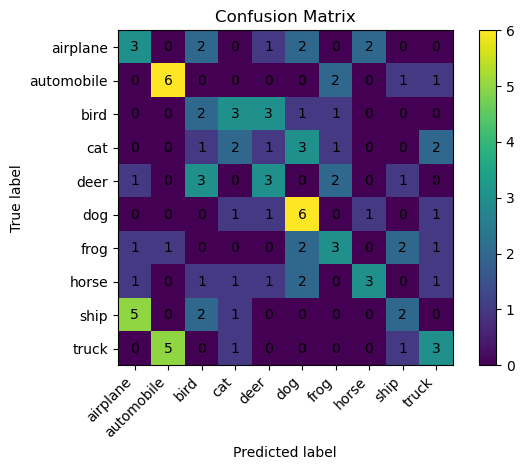

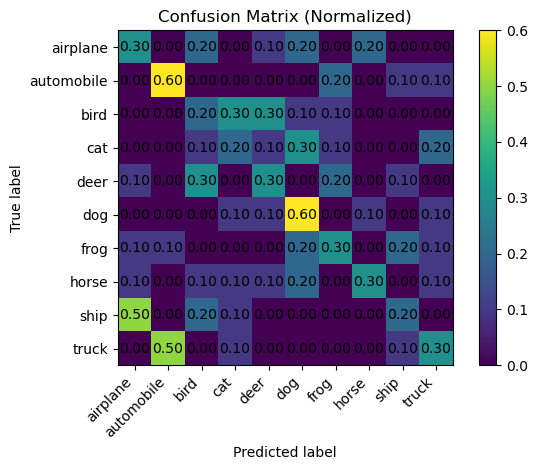

In [69]:
# Execute the method:
execute_machine_learning_stage()



In [70]:
# Compare the size of the files in the RAW and PROCESSED folders
print("For raw files in", RAW_FILES_PATH, "with extension", RAW_FILES_EXTENSION)
list_of_files = find_all_files(RAW_FILES_PATH, RAW_FILES_EXTENSION)
total_raw = compute_total_size(list_of_files)

print("For processed files in", PROCESSED_FILES_PATH, "with extension", PROCESSED_FILES_EXTENSION)
list_of_files = find_all_files(PROCESSED_FILES_PATH, PROCESSED_FILES_EXTENSION)
total_processed = compute_total_size(list_of_files)

print(f"Compression ratio = {total_raw[1] / total_processed[1]:.2f}")

For raw files in ./cifarsubset10 with extension .png
From a total number of files = 500
Total bytes = 89779427 bytes, 85.62 MB. Number of discarded files: 0
For processed files in ./new_dataset with extension .bin
From a total number of files = 500
Total bytes = 24256500 bytes, 23.13 MB. Number of discarded files: 0
Compression ratio = 3.70
